<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/AI/%EA%B0%95%EC%9D%98_8%EA%B8%B0_AI%EA%B0%9C%EB%A1%A0_5%EC%B0%A8%EC%8B%9C_02_Grad_%EB%B6%84%ED%8F%AC%EC%99%80_Scheduler_20260111.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_266/3693092849.py:51: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward(); opt.step(); sched.step()


EP1 loss=0.157 test_acc=0.954
EP2 loss=0.059 test_acc=0.969
EP3 loss=0.025 test_acc=0.978
EP4 loss=0.032 test_acc=0.983
EP5 loss=0.004 test_acc=0.985


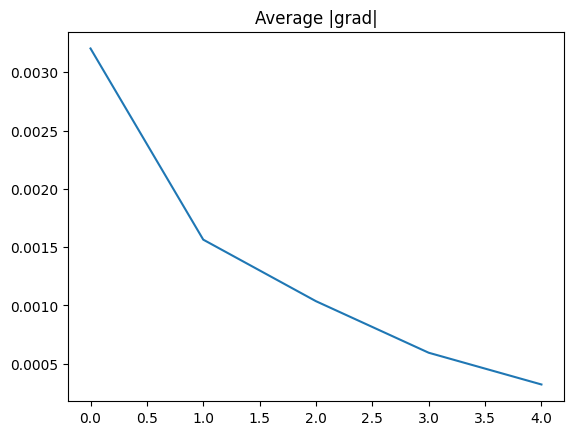

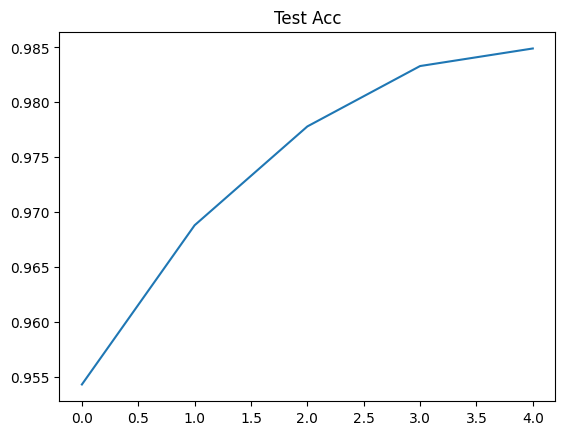

In [2]:
# 5차시 보강 실습: Grad 분포 & Scheduler (Colab 호환)
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

tfm = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST(root='/tmp/mnist', train=True, download=True, transform=tfm)
test_ds  = datasets.MNIST(root='/tmp/mnist', train=False, download=True, transform=tfm)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
        # He 초기화 (ReLU에 적합)
        for m in self.f:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x): return self.f(x)

model = MLP().to(device)
opt = optim.AdamW(model.parameters(), lr=3e-3)
sched = optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-3, steps_per_epoch=len(train_loader), epochs=5)
crit = nn.CrossEntropyLoss()    # 다중분

# Grad 히스토그램 수집용
grads = []
def hook_fn(m, gi, go):
    if isinstance(m, nn.Linear):
        if m.weight.grad is not None:
            grads.append(m.weight.grad.detach().abs().mean().item())

hooks = [m.register_full_backward_hook(hook_fn) for m in model.modules() if isinstance(m, nn.Linear)]

def train_epoch():
    model.train(); tot=0; correct=0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x); loss = crit(out, y)
        loss.backward(); opt.step(); sched.step()
        tot += y.size(0); correct += (out.argmax(1)==y).sum().item()
    return loss.item(), correct/tot

def eval_epoch():
    model.eval(); tot=0; correct=0
    with torch.no_grad():
        for x,y in test_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            tot += y.size(0); correct += (out.argmax(1)==y).sum().item()
    return correct/tot

hist_grad = []
hist_acc  = []
for ep in range(5):
    loss, tr_acc = train_epoch()
    acc = eval_epoch()
    hist_grad.append(sum(grads[-len(train_loader):])/max(1,len(train_loader)))
    hist_acc.append(acc)
    print(f"EP{ep+1} loss={loss:.3f} test_acc={acc:.3f}")

plt.figure(); plt.plot(hist_grad); plt.title('Average |grad|'); plt.show()
plt.figure(); plt.plot(hist_acc); plt.title('Test Acc'); plt.show()

for h in hooks: h.remove()
